In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append("../../")
import numpy as np
from autogluon.timeseries import TimeSeriesDataFrame
from pathlib import Path
import os

In [2]:
# 900 minutes training time.

In [3]:
os.environ["CUDA_VISIBLE_DEVICES"] = "0"


In [ ]:
import json

from dotenv import load_dotenv

# Load environment variables
load_dotenv()

short_datasets = "m4_yearly m4_quarterly m4_monthly m4_weekly m4_daily m4_hourly electricity/15T electricity/H electricity/D electricity/W solar/10T solar/H solar/D solar/W hospital covid_deaths us_births/D us_births/M us_births/W saugeenday/D saugeenday/M saugeenday/W temperature_rain_with_missing kdd_cup_2018_with_missing/H kdd_cup_2018_with_missing/D car_parts_with_missing restaurant hierarchical_sales/D hierarchical_sales/W LOOP_SEATTLE/5T LOOP_SEATTLE/H LOOP_SEATTLE/D SZ_TAXI/15T SZ_TAXI/H M_DENSE/H M_DENSE/D ett1/15T ett1/H ett1/D ett1/W ett2/15T ett2/H ett2/D ett2/W jena_weather/10T jena_weather/H jena_weather/D bitbrains_fast_storage/5T bitbrains_fast_storage/H bitbrains_rnd/5T bitbrains_rnd/H bizitobs_application bizitobs_service bizitobs_l2c/5T bizitobs_l2c/H"
med_long_datasets = "electricity/15T electricity/H solar/10T solar/H kdd_cup_2018_with_missing/H LOOP_SEATTLE/5T LOOP_SEATTLE/H SZ_TAXI/15T M_DENSE/H ett1/15T ett1/H ett2/15T ett2/H jena_weather/10T jena_weather/H bitbrains_fast_storage/5T bitbrains_rnd/5T bizitobs_application bizitobs_service bizitobs_l2c/5T bizitobs_l2c/H"
#med_long_datasets = "ett1/15T"
PRETTY_NAMES = {
    "saugeenday": "saugeen",
    "temperature_rain_with_missing": "temperature_rain",
    "kdd_cup_2018_with_missing": "kdd_cup_2018",
    "car_parts_with_missing": "car_parts",
}
# all_datasets = list(set(short_datasets.split() + med_long_datasets.split()))
all_datasets = list(set(med_long_datasets.split()))

dataset_properties_map = json.load(open("dataset_properties.json"))

sort datasets accoring to length

In [5]:
from gift_eval.data import Dataset

# Step 1: Split and deduplicate dataset names
all_datasets = list(set(med_long_datasets.split()))

# Step 2: Create a list of (dataset_name, series_length) tuples
dataset_lengths = [
    (d, Dataset(name=d, term="medium", to_univariate=False).sum_series_length)
    for d in all_datasets
]

# Step 3: Sort the list by series_length (ascending or descending)
sorted_datasets = sorted(dataset_lengths, key=lambda x: x[1], reverse=False)  # ascending
# sorted_datasets = sorted(dataset_lengths, key=lambda x: x[1], reverse=True)  # descending

# Optional: extract just the sorted dataset names
all_datasets = [d for d, _ in sorted_datasets]

/home/skowronek/.conda/envs/thesis/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [6]:
from gluonts.ev.metrics import (
    MAE,
    MAPE,
    MASE,
    MSE,
    MSIS,
    ND,
    NRMSE,
    RMSE,
    SMAPE,
    MeanWeightedSumQuantileLoss,
)

# Instantiate the metrics
metrics = [
    MSE(forecast_type="mean"),
    MSE(forecast_type=0.5),
    MAE(),
    MASE(),
    MAPE(),
    SMAPE(),
    MSIS(),
    RMSE(),
    NRMSE(),
    ND(),
    MeanWeightedSumQuantileLoss(
        quantile_levels=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    ),
]

Chronos Predictor

In [7]:
from src.pipeline.pipeline import ForecastingPipeline
from src.predictors.chronos import Chronos
from typing import List
from gluonts.model.forecast import QuantileForecast

In [8]:
# allow to use a single model with multiple PP and record all results -> for efficiency.

In [9]:
from src.pipeline.pipeline import ForecastingPipeline
from src.postprocessors.eqc import PostprocessorEQC
from src.postprocessors.qr import PostprocessorFastQR
from src.postprocessors.mle import PostprocessorMLE, PostprocessorFastMLE
from src.predictors.chronos import Chronos
from src.core.timeseries_evaluation import ForecastCollection
from typing import List, Dict
from gluonts.model.forecast import QuantileForecast
import math

def _batched(iterable, n):
    batch = []
    for x in iterable:
        batch.append(x)
        if len(batch) == n:
            yield batch
            batch = []
    if batch:
        yield batch

MODEL_NAME = "chronos_bolt_tiny_ft_v2"
PP_QR_NAME = "chronos_bolt_tiny_ft_v2_pp_fasterqr"
PP_EQC_NAME = "chronos_bolt_tiny_ft_v2_pp"
PP_MLE_NAME = "chronos_bolt_tiny_ft_v2_pp_mle"
MODEL_LIST = [MODEL_NAME, PP_MLE_NAME]#,PP_QR_NAME, PP_EQC_NAME]
class ChronosWrapper():
    def __init__(self, prediction_length, freq):
        self.prediction_length = prediction_length
        lead_times = np.arange(1,self.prediction_length+1)
        self.pipeline = ForecastingPipeline(model=Chronos, 
            model_kwargs={"name": MODEL_NAME,"pretrained_model_name_or_path": "amazon/chronos-bolt-tiny", "device_map": "cuda", "lead_times": lead_times, "finetuning_schedule": ["full"], "finetuning_adjust_pretrained_prediction_length": False, "finetuning_hp_search":False,}, 
            postprocessors=[#PostprocessorFastQR,
                            #PostprocessorEQC,
                            PostprocessorFastMLE,
                            ],
            postprocessor_kwargs = [
                               #{"n_jobs": 12, "name": PP_QR_NAME, "device": "cuda"},
                               #{"n_jobs": 12, "name": PP_EQC_NAME},
                                {"n_jobs": 12, "name": PP_MLE_NAME},
                                ],
            freq=freq,
            output_dir=Path("./results/gift-eval"))
        
    def train(self, train_data_input: Dataset):
        data_train = TimeSeriesDataFrame(train_data_input)
        del train_data_input
        self.pipeline.train_predictor_model(data_train)

    def predict(self, test_data_input: Dataset, batch_size: int = 1024) -> Dict[str, List[QuantileForecast]]:

            forecasts: Dict[str, List[QuantileForecast]] = {m: [] for m in MODEL_LIST}
            batch_size = 128

            try:
                total_items = len(test_data_input)
                total_batches = math.ceil(total_items / batch_size)
            except TypeError:
                total_items = None
                total_batches = None


            for batch_idx, batch in enumerate(_batched(test_data_input, batch_size), start=1):
                if total_batches is not None:
                    print(f"[{batch_idx}/{total_batches}] Processing batch of size {len(batch)}...")
                else:
                    print(f"[{batch_idx}] Processing batch of size {len(batch)}...")

                df_batch = TimeSeriesDataFrame(batch)
                calibration_preds = self.pipeline.auto_generate_calibration_forecasts(df_batch, max_calibration_samples=500)
                self.pipeline.train_postprocessors(calibration_preds[MODEL_NAME])
                result = self.pipeline.generate_forecasts(data_test=df_batch)
                result = self.pipeline.apply_postprocessors_to_forecasts(result)
                for method, fc in result.items():
                    forecasts[method].extend(fc.to_QuantileForecast())
            return forecasts

In [13]:
ds_name = all_datasets[1]
ds_name = "solar/H"
term = "long"

In [21]:
# Initialize the dataset
to_univariate = (
    False
    if Dataset(name=ds_name, term=term, to_univariate=False).target_dim == 1
    else True
)
dataset = Dataset(name=ds_name, term=term, to_univariate=to_univariate)
print(f"Dataset size: {len(dataset.test_data)}")

Dataset size: 274


In [23]:
Dataset(name=ds_name, term=term, to_univariate=False).target_dim

1

In [22]:
TimeSeriesDataFrame(dataset.training_dataset)

target
item_id timestamp                  
0       2006-01-01 00:00:00     0.0
        2006-01-01 01:00:00     0.0
        2006-01-01 02:00:00     0.0
        2006-01-01 03:00:00     0.0
        2006-01-01 04:00:00     0.0
...                             ...
136     2006-10-02 19:00:00     0.0
        2006-10-02 20:00:00     0.0
        2006-10-02 21:00:00     0.0
        2006-10-02 22:00:00     0.0
        2006-10-02 23:00:00     0.0

[904200 rows x 1 columns]

In [17]:
TimeSeriesDataFrame(dataset.training_dataset)

target
item_id timestamp                  
0       2006-01-01 00:00:00     0.0
        2006-01-01 01:00:00     0.0
        2006-01-01 02:00:00     0.0
        2006-01-01 03:00:00     0.0
        2006-01-01 04:00:00     0.0
...                             ...
136     2006-10-02 19:00:00     0.0
        2006-10-02 20:00:00     0.0
        2006-10-02 21:00:00     0.0
        2006-10-02 22:00:00     0.0
        2006-10-02 23:00:00     0.0

[904200 rows x 1 columns]

In [53]:
TimeSeriesDataFrame(dataset.validation_dataset).loc[[0]]

target
item_id timestamp                     
0       2020-11-01 00:00:00   0.000000
        2020-11-01 01:00:00   0.000000
        2020-11-01 02:00:00   0.000000
        2020-11-01 03:00:00   0.000000
        2020-11-01 04:00:00   0.000000
...                                ...
        2021-01-20 19:00:00  18.870001
        2021-01-20 20:00:00  19.099167
        2021-01-20 21:00:00  19.192499
        2021-01-20 22:00:00  19.686666
        2021-01-20 23:00:00  19.904167

[1944 rows x 1 columns]

In [57]:
TimeSeriesDataFrame(dataset.test_data.label).loc[[0]]

target
item_id timestamp                     
0       2021-01-21 00:00:00  19.976667
        2021-01-21 01:00:00  20.161667
        2021-01-21 02:00:00  20.049999
        2021-01-21 03:00:00  20.067499
        2021-01-21 04:00:00  20.160000
...                                ...
        2021-02-19 19:00:00  26.890833
        2021-02-19 20:00:00  26.846666
        2021-02-19 21:00:00  26.807501
        2021-02-19 22:00:00  26.746666
        2021-02-19 23:00:00  26.776667

[720 rows x 1 columns]

In [39]:
chronos = ChronosWrapper(600, "10S")

2025-09-15 13:30:09,115 - INFO - base.py - Using the following output directory to store results: results/gift-eval/models/chronos_bolt_tiny_ft_v2
2025-09-15 13:30:09,116 - INFO - chronos.py - Loading Chronos pipeline from model: amazon/chronos-bolt-tiny
2025-09-15 13:30:09,117 - INFO - chronos.py - Initializing Chronos pipeline with model: amazon/chronos-bolt-tiny
2025-09-15 13:30:09,700 - INFO - chronos.py - Final fine-tuning schedule: full
2025-09-15 13:30:09,701 - INFO - base.py - Using the following output directory to store results: results/gift-eval/postprocessors/chronos_bolt_tiny_ft_v2_pp_mle


In [40]:
data_train, data_val = chronos.pipeline.train_predictor_model(TimeSeriesDataFrame(dataset.validation_dataset))

2025-09-15 13:30:12,501 - INFO - <string> - Initializing predictor with model: Chronos
2025-09-15 13:30:12,503 - INFO - base.py - Using the following output directory to store results: results/gift-eval/models/chronos_bolt_tiny_ft_v2
2025-09-15 13:30:12,504 - INFO - chronos.py - Loading Chronos pipeline from model: amazon/chronos-bolt-tiny
2025-09-15 13:30:12,505 - INFO - chronos.py - Initializing Chronos pipeline with model: amazon/chronos-bolt-tiny
2025-09-15 13:30:13,085 - INFO - chronos.py - Final fine-tuning schedule: full
2025-09-15 13:30:13,095 - INFO - <string> - Auto-generating validation data from training data...
2025-09-15 13:30:13,096 - INFO - <string> - Auto-validation using val_window_step=64
2025-09-15 13:30:13,097 - INFO - <string> - Auto-validation using max_val_windows=9
2025-09-15 13:30:13,098 - INFO - pipeline.py - Automatically splitting data into training and validation data...
2025-09-15 13:30:13,110 - INFO - pipeline.py - Split result: 14116 timesteps for train

64 9


In [38]:
data_val.loc[[0]]

target
item_id timestamp                     
0       2023-03-14 05:38:10  79.861473
        2023-03-14 05:38:20  79.612488
        2023-03-14 05:38:30  78.575821
        2023-03-14 05:38:40  79.014130
        2023-03-14 05:38:50  79.422768
...                                ...
        2023-03-14 07:13:20  44.994953
        2023-03-14 07:13:30  44.774551
        2023-03-14 07:13:40  44.614201
        2023-03-14 07:13:50  44.428158
        2023-03-14 07:14:00  44.575089

[576 rows x 1 columns]

In [41]:
chronos.pipeline.auto_generate_calibration_config(TimeSeriesDataFrame(dataset.validation_dataset), 100)

2025-09-15 13:35:32,989 - WARNING - pipeline.py - Using sampling_method='fixed_stride'. Note: if prediction_length << seasonality and max_calibration_samples is small, calibration coverage may be poor. Consider sampling_method='random' instead. TODO: add option to account for seasonality when selecting calibration samples.
2025-09-15 13:35:32,991 - INFO - pipeline.py - Calibration samples per time series: {0: 382, 1: 382}


array([False, False, False, ..., False, False,  True])

# Evaluation

In [13]:
import logging


class WarningFilter(logging.Filter):
    def __init__(self, text_to_filter):
        super().__init__()
        self.text_to_filter = text_to_filter

    def filter(self, record):
        return self.text_to_filter not in record.getMessage()


gts_logger = logging.getLogger("gluonts.model.forecast")
gts_logger.addFilter(
    WarningFilter("The mean prediction is not stored in the forecast data")
)

In [9]:
# TODO: save ft models to disk and allow to load it later.

In [14]:
from gluonts.model.evaluation import evaluate_forecasts
from gluonts.model import Predictor
from gluonts.dataset.split import TestData
from typing import Optional, Union

def evaluate_model(
            model: Predictor,
            *,
            test_data: TestData,
            metrics,
            axis: Optional[Union[int, tuple]] = None,
            batch_size: int = 100,
            mask_invalid_label: bool = True,
            allow_nan_forecast: bool = False,
            seasonality: Optional[int] = None,
        ):
    
    forecasts = model.predict(test_data.input)
    
    fc_evals = {name: evaluate_forecasts(
                forecasts=fc,
                test_data=test_data,
                metrics=metrics,
                axis=axis,
                batch_size=batch_size,
                mask_invalid_label=mask_invalid_label,
                allow_nan_forecast=allow_nan_forecast,
                seasonality=seasonality,
            ) for name, fc in forecasts.items()}

    return fc_evals


In [22]:
# next: store predictions to reload easily

In [15]:
from pympler import asizeof

def get_deep_size_mb(obj):
    return asizeof.asizeof(obj) / (1024 ** 2)


In [ ]:
from gift_eval.data import Dataset
from gluonts.time_feature import get_seasonality


ds_name = all_datasets[0]
# Initialize the dataset
to_univariate = (
    False
    if Dataset(name=ds_name, term="medium", to_univariate=False).target_dim == 1
    else True
)
dataset = Dataset(name=ds_name, term="medium", to_univariate=to_univariate)
season_length = get_seasonality(dataset.freq)
print(f"Dataset size: {len(dataset.test_data)}")



print(f"Size: {get_size_mb(dataset):.2f} MB")


In [30]:
t = TimeSeriesDataFrame(dataset.training_dataset)
print(f"Deep size: {get_deep_size_mb(t):.2f} MB")


Deep size: 344.50 MB


In [36]:
import csv
import os

from gluonts.time_feature import get_seasonality

from gift_eval.data import Dataset

csv_file_paths = {}
# Iterate over all available datasets
for m in MODEL_LIST:
    output_dir = f"../results/{m}"
    # Ensure the output directory exists
    os.makedirs(output_dir, exist_ok=True)

    # Define the path for the CSV file
    csv_file_paths[m] = os.path.join(output_dir, "all_results.csv")

    pretty_names = {
        "saugeenday": "saugeen",
        "temperature_rain_with_missing": "temperature_rain",
        "kdd_cup_2018_with_missing": "kdd_cup_2018",
        "car_parts_with_missing": "car_parts",
    }

    with open(csv_file_paths[m], "w", newline="") as csvfile:
        writer = csv.writer(csvfile)

        # Write the header
        writer.writerow(
            [
                "dataset",
                "model",
                "eval_metrics/MSE[mean]",
                "eval_metrics/MSE[0.5]",
                "eval_metrics/MAE[0.5]",
                "eval_metrics/MASE[0.5]",
                "eval_metrics/MAPE[0.5]",
                "eval_metrics/sMAPE[0.5]",
                "eval_metrics/MSIS",
                "eval_metrics/RMSE[mean]",
                "eval_metrics/NRMSE[mean]",
                "eval_metrics/ND[0.5]",
                "eval_metrics/mean_weighted_sum_quantile_loss",
                "domain",
                "num_variates",
            ]
        )

for ds_num, ds_name in enumerate(all_datasets):
    ds_key = ds_name.split("/")[0]
    print(f"Processing dataset: {ds_name} ({ds_num + 1} of {len(all_datasets)})")
    terms = ["medium", "long"]
    for term in terms:
        if (
            term == "medium" or term == "long"
        ) and ds_name not in med_long_datasets.split():
            continue

        if "/" in ds_name:
            ds_key = ds_name.split("/")[0]
            ds_freq = ds_name.split("/")[1]
            ds_key = ds_key.lower()
            ds_key = pretty_names.get(ds_key, ds_key)
        else:
            ds_key = ds_name.lower()
            ds_key = pretty_names.get(ds_key, ds_key)
            ds_freq = dataset_properties_map[ds_key]["frequency"]
        ds_config = f"{ds_key}/{ds_freq}/{term}"

        # Initialize the dataset
        to_univariate = (
            False
            if Dataset(name=ds_name, term=term, to_univariate=False).target_dim == 1
            else True
        )
        dataset = Dataset(name=ds_name, term=term, to_univariate=to_univariate)
        season_length = get_seasonality(dataset.freq)
        print(f"Dataset size: {len(dataset.test_data)}")

        predictor = ChronosWrapper(dataset.prediction_length, dataset.freq)
        
        # predictor.train(dataset.validation_dataset)

        # preds = predictor.generate_calibration_forecasts(dataset.test_data.input)
        # predictor.train_postprocessor(preds)
        # Measure the time taken for evaluation
        res_all = evaluate_model(
            predictor,
            test_data=dataset.test_data,
            metrics=metrics,
            batch_size=1024,
            axis=None,
            mask_invalid_label=True,
            allow_nan_forecast=False,
            seasonality=season_length,
        )

        for model_name, csv_file_path in csv_file_paths.items():
            # Append the results to the CSV file
            res = res_all[model_name]
            with open(csv_file_path, "a", newline="") as csvfile:
                writer = csv.writer(csvfile)
                writer.writerow(
                    [
                        ds_config,
                        model_name,
                        res["MSE[mean]"][0],
                        res["MSE[0.5]"][0],
                        res["MAE[0.5]"][0],
                        res["MASE[0.5]"][0],
                        res["MAPE[0.5]"][0],
                        res["sMAPE[0.5]"][0],
                        res["MSIS"][0],
                        res["RMSE[mean]"][0],
                        res["NRMSE[mean]"][0],
                        res["ND[0.5]"][0],
                        res["mean_weighted_sum_quantile_loss"][0],
                        dataset_properties_map[ds_key]["domain"],
                        dataset_properties_map[ds_key]["num_variates"],
                    ]
                )

            print(f"Results for {ds_name} have been written to {csv_file_path}")
        del predictor, dataset

2025-08-04 17:24:05,822 - INFO - base.py - Using the following output directory to store results: results/gift-eval/models/chronos_bolt_tiny_ft_v2
2025-08-04 17:24:05,823 - INFO - chronos.py - Loading Chronos pipeline from model: amazon/chronos-bolt-tiny
2025-08-04 17:24:05,824 - INFO - chronos.py - Initializing Chronos pipeline with model: amazon/chronos-bolt-tiny


Processing dataset: bizitobs_application (1 of 21)
Dataset size: 4


2025-08-04 17:24:06,395 - INFO - base.py - Using the following output directory to store results: results/gift-eval/postprocessors/chronos_bolt_tiny_ft_v2_pp_mle


[1/1] Processing batch of size 4...


2025-08-04 17:24:06,994 - INFO - pipeline.py - Automatically determined window_step: 20
2025-08-04 17:24:07,012 - INFO - pipeline.py - Starting forecast generation of model chronos_bolt_tiny_ft_v2 for data_test from 2023-03-13 10:01:50 to 2023-03-14 08:54:00


Predicting using Chronos:   0%|          | 0/4 [00:00<?, ?it/s]

/home/skowronek/master-thesis/chronos-forecasting/src/chronos/chronos_bolt.py:627: UserWarning: We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
  warnings.warn(msg)
2025-08-04 17:24:29,905 - INFO - base.py - Chronos: Time to generate forecasts in seconds: 22.89
2025-08-04 17:24:29,906 - INFO - pipeline.py - Start training postprocessors...
2025-08-04 17:24:29,907 - INFO - base.py - Using the following output directory to store results: results/gift-eval/postprocessors/chronos_bolt_tiny_ft_v2_pp_mle
Fitting chronos_bolt_tiny_ft_v2_pp_mle for each time series (item):   0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

Fitting chronos_bolt_tiny_ft_v2_pp_mle for each time series (item):   0%|          | 0/4 [34:56<?, ?it/s]


KeyboardInterrupt: 

In [14]:
ds_name = all_datasets[-20]
term = "medium"

In [16]:
from gluonts.time_feature import get_seasonality

from gift_eval.data import Dataset
# Initialize the dataset
to_univariate = (
    False
    if Dataset(name=ds_name, term=term, to_univariate=False).target_dim == 1
    else True
)
dataset = Dataset(name=ds_name, term=term, to_univariate=to_univariate)
season_length = get_seasonality(dataset.freq)
print(f"Dataset size: {len(dataset.test_data)}")

predictor = ChronosWrapper(dataset.prediction_length, dataset.freq)
#predictor.train(dataset.validation_dataset)

2025-08-04 17:10:08,909 - INFO - base.py - Using the following output directory to store results: results/gift-eval/models/chronos_bolt_tiny_ft_v2
2025-08-04 17:10:08,910 - INFO - chronos.py - Loading Chronos pipeline from model: amazon/chronos-bolt-tiny
2025-08-04 17:10:08,911 - INFO - chronos.py - Initializing Chronos pipeline with model: amazon/chronos-bolt-tiny


Dataset size: 7


2025-08-04 17:10:09,630 - INFO - base.py - Using the following output directory to store results: results/gift-eval/postprocessors/chronos_bolt_tiny_ft_v2_pp_fasterqr
2025-08-04 17:10:09,631 - INFO - base.py - Using the following output directory to store results: results/gift-eval/postprocessors/chronos_bolt_tiny_ft_v2_pp
2025-08-04 17:10:09,632 - INFO - base.py - Using the following output directory to store results: results/gift-eval/postprocessors/chronos_bolt_tiny_ft_v2_pp_mle


In [18]:
for batch_idx, batch in enumerate(_batched(dataset.test_data.input, 512), start=1):   
    calibration_preds = predictor.pipeline.auto_generate_calibration_forecasts(TimeSeriesDataFrame(batch), max_calibration_samples=500)
    predictor.pipeline.train_postprocessors(calibration_preds[MODEL_NAME])
    result = predictor.pipeline.generate_forecasts(data_test=TimeSeriesDataFrame(batch))
    result = predictor.pipeline.apply_postprocessors_to_forecasts(result)
    break

2025-08-04 17:12:17,687 - INFO - pipeline.py - Automatically determined window_step: 5
2025-08-04 17:12:17,702 - INFO - pipeline.py - Starting forecast generation of model chronos_bolt_tiny_ft_v2 for data_test from 2020-11-01 00:00:00 to 2021-01-30 23:00:00


Predicting using Chronos:   0%|          | 0/6 [00:00<?, ?it/s]

/home/skowronek/master-thesis/chronos-forecasting/src/chronos/chronos_bolt.py:627: UserWarning: We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
  warnings.warn(msg)
Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.
2025-08-04 17:12:42,250 - INFO - base.py - Chronos: Time to generate forecasts in seconds: 24.55
2025-08-04 17:12:42,251 - INFO - pipeline.py - Start training postprocessors...
2025-08-04 17:12:42,252 - INFO - base.py - Using the following output directory to store results: results/gift-eval/postprocessors/chronos_bolt_tiny_ft_v2_pp_fasterqr
2025-08-04 17:12:42,253 - INFO - base.py - Using the following output directory to store results: results/gift-eval/postprocessors/chronos_bolt_tiny_ft_v2_pp
2025-08-04

  0%|          | 0/7 [00:00<?, ?it/s]

2025-08-04 17:12:47,019 - INFO - base.py - Time to fit chronos_bolt_tiny_ft_v2_pp_fasterqr in seconds: 4.76


...

2025-08-04 17:12:55,091 - INFO - base.py - Time to fit chronos_bolt_tiny_ft_v2_pp in seconds: 8.07



  0%|          | 0/7 [00:00<?, ?it/s]

Fitting chronos_bolt_tiny_ft_v2_pp for each time series (item):   0%|          | 0/7 [00:08<?, ?it/s]
2025-08-04 17:14:24,111 - INFO - base.py - Time to fit chronos_bolt_tiny_ft_v2_pp_mle in seconds: 89.02
2025-08-04 17:14:24,113 - INFO - pipeline.py - Postprocessors training completed in 101.860929 seconds.
2025-08-04 17:14:24,440 - INFO - pipeline.py - Starting forecast generation of model chronos_bolt_tiny_ft_v2 for data_test from 2020-11-01 00:00:00 to 2021-01-30 23:00:00


Predicting using Chronos:   0%|          | 0/1 [00:00<?, ?it/s]

/home/skowronek/master-thesis/chronos-forecasting/src/chronos/chronos_bolt.py:627: UserWarning: We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
  warnings.warn(msg)
Exception in thread QueueFeederThread:
Traceback (most recent call last):
  File "/home/skowronek/.conda/envs/thesis/lib/python3.12/multiprocessing/queues.py", line 259, in _feed
Exception ignored in: <function _ConnectionBase.__del__ at 0x7f437601e020>
Traceback (most recent call last):
  File "/home/skowronek/.conda/envs/thesis/lib/python3.12/multiprocessing/connection.py", line 133, in __del__
    reader_close()
  File "/home/skowronek/.conda/envs/thesis/lib/python3.12/multiprocessing/connection.py", line 178, in close
    self._close()
  File "/home/skowronek/.conda/envs/thesis/lib/python3.12/multiprocessing/connection.py", line 377, in _close
    self._close()
  File "/home/skowronek/.conda/envs/thesis/lib/python3.12/multiprocessing/c

In [28]:
forecasts = {}
for method, fc in result.items():
    forecasts[method] = []
    forecasts[method].extend(fc.to_QuantileForecast())

In [ ]:
result[""].get_time_series_forecast(30).plot_forecasts(context_length=10)

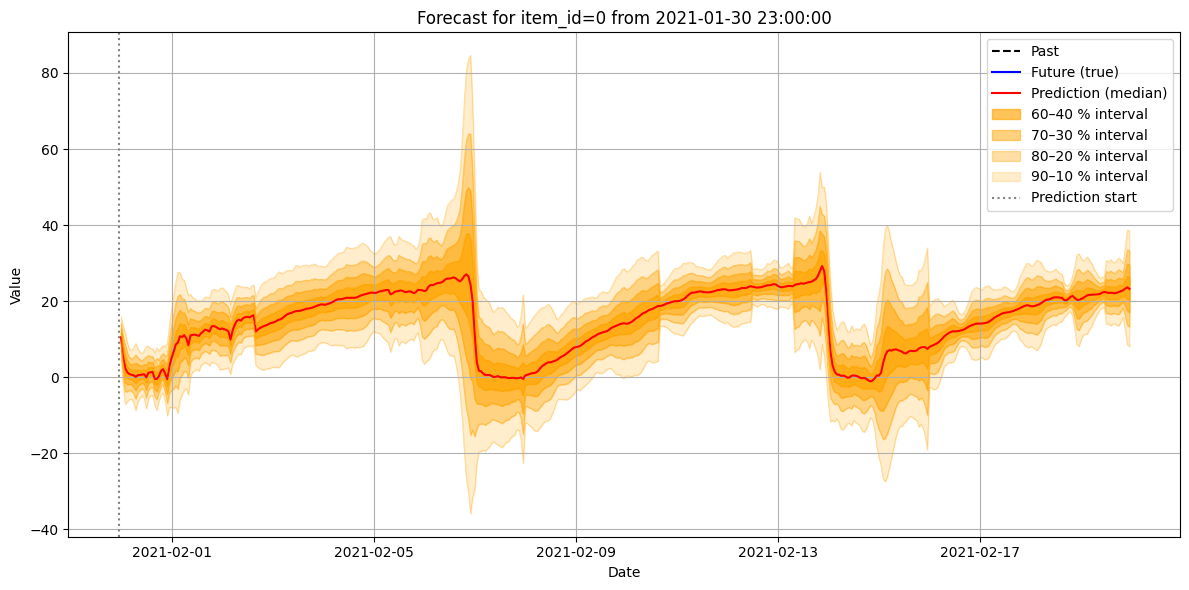

In [25]:
result["chronos_bolt_tiny_ft_v2_pp_mle"].get_time_series_forecast(0).plot_forecasts(context_length=10)

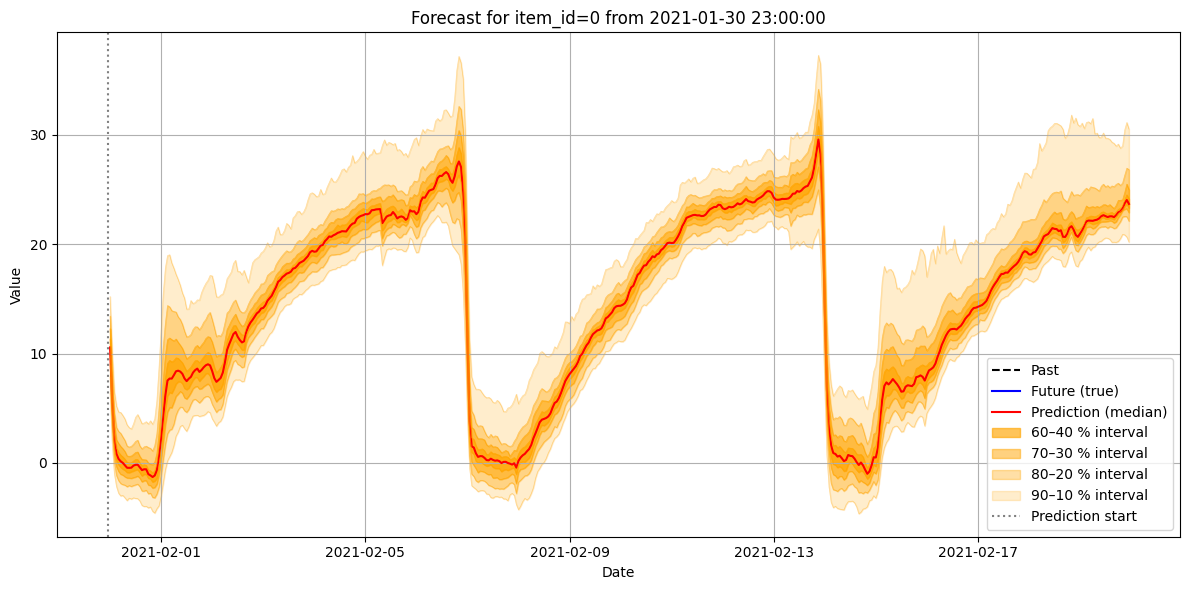

In [23]:
result["chronos_bolt_tiny_ft_v2_pp"].get_time_series_forecast(0).plot_forecasts(context_length=10)

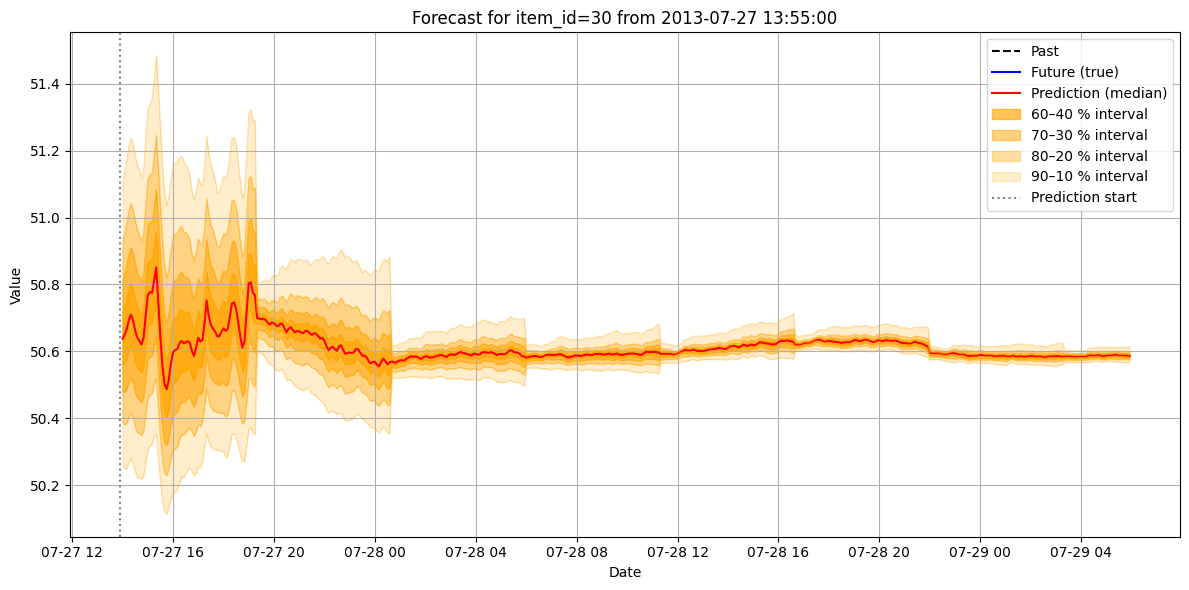

In [66]:
result["chronos_bolt_tiny_ft_v2"].get_time_series_forecast(30).plot_forecasts(context_length=10)

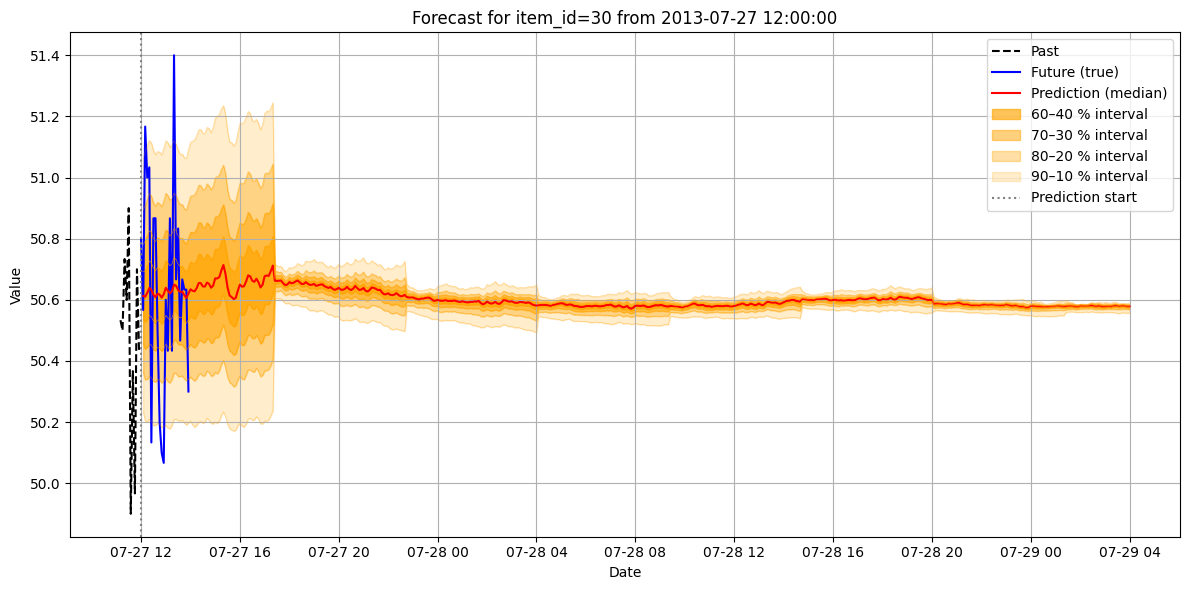

In [54]:
result["chronos_bolt_tiny_ft_v2"].get_time_series_forecast(30).plot_forecasts(context_length=10)

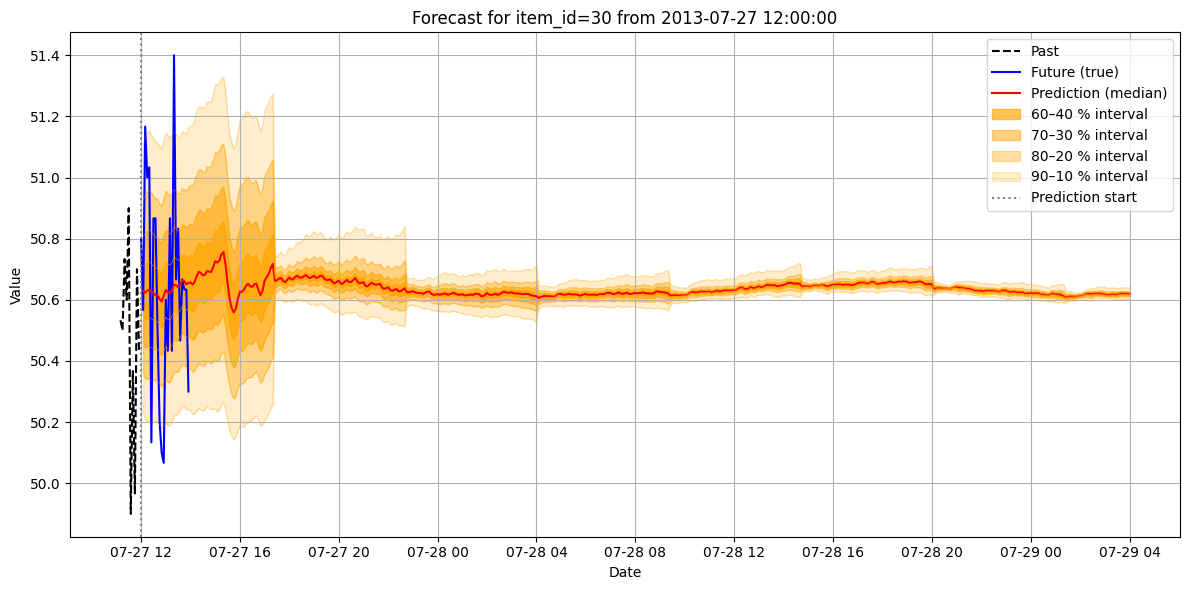

In [50]:
result["chronos_bolt_tiny_ft_v2"].get_time_series_forecast(30).plot_forecasts(context_length=10)

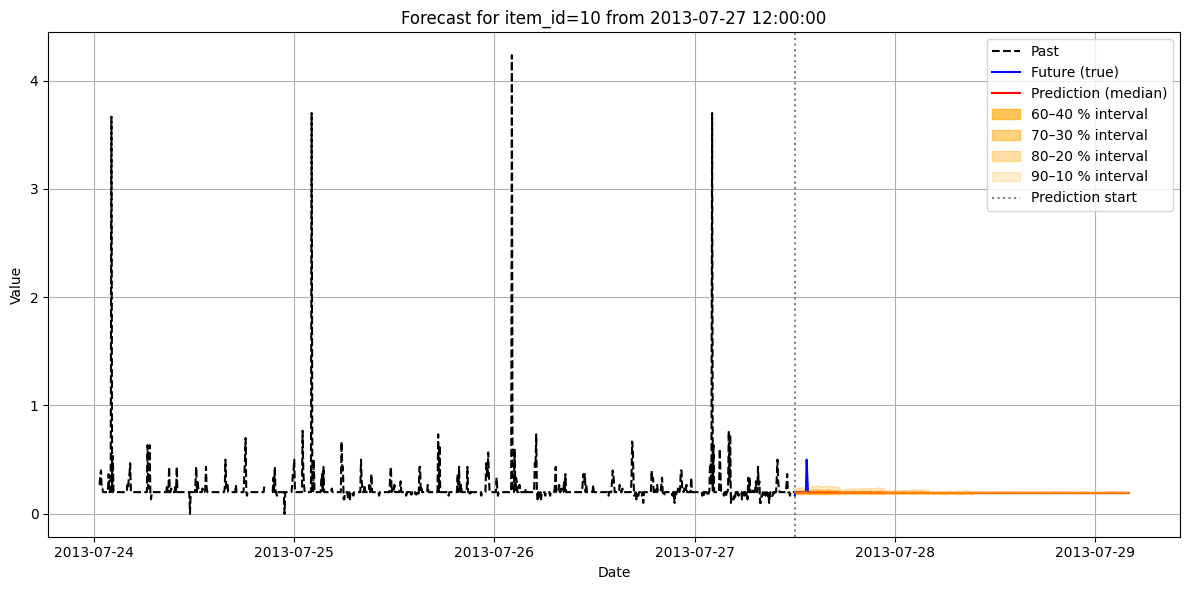

In [45]:
result["chronos_bolt_tiny_ft_v2"].get_time_series_forecast(10).plot_forecasts(context_length=1000)

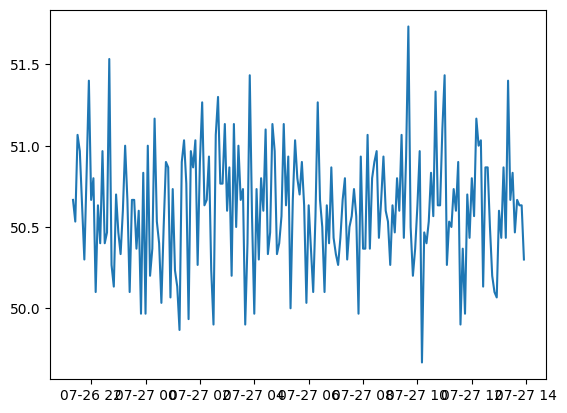

In [35]:
import matplotlib.pyplot as plt

plt.plot(tsdf.loc[30].iloc[-200:])

In [20]:
import csv
import os
import psutil
import gc
import time

from gluonts.time_feature import get_seasonality
from gift_eval.data import Dataset

process = psutil.Process(os.getpid())

def print_mem(label=""):
    mem = process.memory_info().rss / 1024 ** 2  # in MB
    print(f"[MEM] {label}: {mem:.2f} MB")

def clear_mem():
    gc.collect()
    print_mem("After GC")

csv_file_paths = {}

for m in MODEL_LIST:
    output_dir = f"../results/{m}"
    os.makedirs(output_dir, exist_ok=True)
    csv_file_paths[m] = os.path.join(output_dir, "all_results.csv")

    with open(csv_file_paths[m], "w", newline="") as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(
            [
                "dataset",
                "model",
                "eval_metrics/MSE[mean]",
                "eval_metrics/MSE[0.5]",
                "eval_metrics/MAE[0.5]",
                "eval_metrics/MASE[0.5]",
                "eval_metrics/MAPE[0.5]",
                "eval_metrics/sMAPE[0.5]",
                "eval_metrics/MSIS",
                "eval_metrics/RMSE[mean]",
                "eval_metrics/NRMSE[mean]",
                "eval_metrics/ND[0.5]",
                "eval_metrics/mean_weighted_sum_quantile_loss",
                "domain",
                "num_variates",
            ]
        )

for ds_num, ds_name in enumerate(all_datasets):
    ds_key = ds_name.split("/")[0]
    print(f"\n=== Processing dataset: {ds_name} ({ds_num + 1} of {len(all_datasets)}) ===")
    terms = ["medium", "long"]
    for term in terms:
        if (
            term == "medium" or term == "long"
        ) and ds_name not in med_long_datasets.split():
            continue

        if "/" in ds_name:
            ds_key = ds_name.split("/")[0]
            ds_freq = ds_name.split("/")[1]
            ds_key = ds_key.lower()
            ds_key = pretty_names.get(ds_key, ds_key)
        else:
            ds_key = ds_name.lower()
            ds_key = pretty_names.get(ds_key, ds_key)
            ds_freq = dataset_properties_map[ds_key]["frequency"]
        ds_config = f"{ds_key}/{ds_freq}/{term}"

        print_mem("Before Dataset Init")
        to_univariate = (
            False
            if Dataset(name=ds_name, term=term, to_univariate=False).target_dim == 1
            else True
        )
        dataset = Dataset(name=ds_name, term=term, to_univariate=to_univariate)
        print_mem("After Dataset Init")

        season_length = get_seasonality(dataset.freq)
        print(f"Dataset size: {len(dataset.test_data)}")

        print_mem("Before Model Init")
        predictor = ChronosWrapper(dataset.prediction_length, dataset.freq)
        print_mem("Before Training")
        predictor.train(dataset.validation_dataset)
        print_mem("After Training")

        print_mem("Before Evaluation")
        res_all = evaluate_model(
            predictor,
            test_data=dataset.test_data,
            metrics=metrics,
            batch_size=1024,
            axis=None,
            mask_invalid_label=True,
            allow_nan_forecast=False,
            seasonality=season_length,
        )
        print_mem("After Evaluation")

        for model_name, csv_file_path in csv_file_paths.items():
            res = res_all[model_name]
            with open(csv_file_path, "a", newline="") as csvfile:
                writer = csv.writer(csvfile)
                writer.writerow(
                    [
                        ds_config,
                        model_name,
                        res["MSE[mean]"][0],
                        res["MSE[0.5]"][0],
                        res["MAE[0.5]"][0],
                        res["MASE[0.5]"][0],
                        res["MAPE[0.5]"][0],
                        res["sMAPE[0.5]"][0],
                        res["MSIS"][0],
                        res["RMSE[mean]"][0],
                        res["NRMSE[mean]"][0],
                        res["ND[0.5]"][0],
                        res["mean_weighted_sum_quantile_loss"][0],
                        dataset_properties_map[ds_key]["domain"],
                        dataset_properties_map[ds_key]["num_variates"],
                    ]
                )

            print(f"Results for {ds_name} have been written to {csv_file_path}")

        # Clean up to


2025-08-01 17:09:02,690 - INFO - base.py - Using the following output directory to store results: results/gift-eval/models/chronos_bolt_tiny_ft_v2
2025-08-01 17:09:02,691 - INFO - chronos.py - Loading Chronos pipeline from model: amazon/chronos-bolt-tiny
2025-08-01 17:09:02,692 - INFO - chronos.py - Initializing Chronos pipeline with model: amazon/chronos-bolt-tiny



=== Processing dataset: bizitobs_application (1 of 21) ===
[MEM] Before Dataset Init: 2247.09 MB
[MEM] After Dataset Init: 2247.16 MB
Dataset size: 4
[MEM] Before Model Init: 2247.16 MB


2025-08-01 17:09:03,358 - INFO - base.py - Using the following output directory to store results: results/gift-eval/postprocessors/chronos_bolt_tiny_ft_v2_pp_fasterqr
2025-08-01 17:09:03,359 - INFO - base.py - Using the following output directory to store results: results/gift-eval/postprocessors/chronos_bolt_tiny_ft_v2_pp


[MEM] Before Training: 2248.34 MB


2025-08-01 17:09:03,907 - INFO - <string> - Initializing predictor with model: Chronos
2025-08-01 17:09:03,908 - INFO - base.py - Using the following output directory to store results: results/gift-eval/models/chronos_bolt_tiny_ft_v2
2025-08-01 17:09:03,909 - INFO - chronos.py - Loading Chronos pipeline from model: amazon/chronos-bolt-tiny
2025-08-01 17:09:03,910 - INFO - chronos.py - Initializing Chronos pipeline with model: amazon/chronos-bolt-tiny
2025-08-01 17:09:04,647 - INFO - <string> - Inferring validation set from training data...
2025-08-01 17:09:04,647 - INFO - pipeline.py - Automatically splitting data into training and validation data...
2025-08-01 17:09:04,652 - INFO - pipeline.py - Split result: 14756 timesteps for training (96.6%), 512 timesteps for validation (3.4%)
2025-08-01 17:09:04,652 - INFO - pipeline.py - Split sizes per series: 7378 raw values for training, 256 for validation
2025-08-01 17:09:04,653 - INFO - pipeline.py - Sliding windows: 115 training windows, 

trainable params: 8652672 || all params: 8652672 || trainable%: 100.0


KeyboardInterrupt: 

In [12]:
import csv
import os

from gluonts.time_feature import get_seasonality

from gift_eval.data import Dataset

csv_file_paths = {}
# Iterate over all available datasets
for m in MODEL_LIST:
    output_dir = f"../results/{m}"
    # Ensure the output directory exists
    os.makedirs(output_dir, exist_ok=True)

    # Define the path for the CSV file
    csv_file_paths[m] = os.path.join(output_dir, "all_results.csv")

    pretty_names = {
        "saugeenday": "saugeen",
        "temperature_rain_with_missing": "temperature_rain",
        "kdd_cup_2018_with_missing": "kdd_cup_2018",
        "car_parts_with_missing": "car_parts",
    }

    with open(csv_file_paths[m], "w", newline="") as csvfile:
        writer = csv.writer(csvfile)

        # Write the header
        writer.writerow(
            [
                "dataset",
                "model",
                "eval_metrics/MSE[mean]",
                "eval_metrics/MSE[0.5]",
                "eval_metrics/MAE[0.5]",
                "eval_metrics/MASE[0.5]",
                "eval_metrics/MAPE[0.5]",
                "eval_metrics/sMAPE[0.5]",
                "eval_metrics/MSIS",
                "eval_metrics/RMSE[mean]",
                "eval_metrics/NRMSE[mean]",
                "eval_metrics/ND[0.5]",
                "eval_metrics/mean_weighted_sum_quantile_loss",
                "domain",
                "num_variates",
            ]
        )

for ds_num, ds_name in enumerate(all_datasets):
    ds_key = ds_name.split("/")[0]
    print(f"Processing dataset: {ds_name} ({ds_num + 1} of {len(all_datasets)})")
    terms = ["medium", "long"]
    for term in terms:
        if (
            term == "medium" or term == "long"
        ) and ds_name not in med_long_datasets.split():
            continue

        if "/" in ds_name:
            ds_key = ds_name.split("/")[0]
            ds_freq = ds_name.split("/")[1]
            ds_key = ds_key.lower()
            ds_key = pretty_names.get(ds_key, ds_key)
        else:
            ds_key = ds_name.lower()
            ds_key = pretty_names.get(ds_key, ds_key)
            ds_freq = dataset_properties_map[ds_key]["frequency"]
        ds_config = f"{ds_key}/{ds_freq}/{term}"

        # Initialize the dataset
        to_univariate = (
            False
            if Dataset(name=ds_name, term=term, to_univariate=False).target_dim == 1
            else True
        )
        dataset = Dataset(name=ds_name, term=term, to_univariate=to_univariate)
        season_length = get_seasonality(dataset.freq)
        print(f"Dataset size: {len(dataset.test_data)}")

        predictor = ChronosWrapper(dataset.prediction_length, dataset.freq)
        predictor.train(dataset.validation_dataset)

        # preds = predictor.generate_calibration_forecasts(dataset.test_data.input)
        # predictor.train_postprocessor(preds)
        # Measure the time taken for evaluation
        res_all = evaluate_model(
            predictor,
            test_data=dataset.test_data,
            metrics=metrics,
            batch_size=1024,
            axis=None,
            mask_invalid_label=True,
            allow_nan_forecast=False,
            seasonality=season_length,
        )

        for model_name, csv_file_path in csv_file_paths.items():
            # Append the results to the CSV file
            res = res_all[model_name]
            with open(csv_file_path, "a", newline="") as csvfile:
                writer = csv.writer(csvfile)
                writer.writerow(
                    [
                        ds_config,
                        model_name,
                        res["MSE[mean]"][0],
                        res["MSE[0.5]"][0],
                        res["MAE[0.5]"][0],
                        res["MASE[0.5]"][0],
                        res["MAPE[0.5]"][0],
                        res["sMAPE[0.5]"][0],
                        res["MSIS"][0],
                        res["RMSE[mean]"][0],
                        res["NRMSE[mean]"][0],
                        res["ND[0.5]"][0],
                        res["mean_weighted_sum_quantile_loss"][0],
                        dataset_properties_map[ds_key]["domain"],
                        dataset_properties_map[ds_key]["num_variates"],
                    ]
                )

            print(f"Results for {ds_name} have been written to {csv_file_path}")
        del predictor, dataset

Processing dataset: bitbrains_fast_storage/5T (1 of 3)


2025-07-31 23:34:23,473 - INFO - base.py - Using the following output directory to store results: results/gift-eval/models/chronos_bolt_tiny_ft
2025-07-31 23:34:23,474 - INFO - chronos.py - Loading Chronos pipeline from model: amazon/chronos-bolt-tiny
2025-07-31 23:34:23,475 - INFO - chronos.py - Initializing Chronos pipeline with model: amazon/chronos-bolt-tiny


Dataset size: 5000


2025-07-31 23:34:24,061 - INFO - base.py - Using the following output directory to store results: results/gift-eval/postprocessors/chronos_bolt_tiny_ft_pp_fasterqr
2025-07-31 23:34:24,062 - INFO - base.py - Using the following output directory to store results: results/gift-eval/postprocessors/chronos_bolt_tiny_ft_pp
2025-07-31 23:34:31,585 - INFO - pipeline.py - Initializing predictor with model: Chronos
2025-07-31 23:34:31,587 - INFO - base.py - Using the following output directory to store results: results/gift-eval/models/chronos_bolt_tiny_ft
2025-07-31 23:34:31,588 - INFO - chronos.py - Loading Chronos pipeline from model: amazon/chronos-bolt-tiny
2025-07-31 23:34:31,588 - INFO - chronos.py - Initializing Chronos pipeline with model: amazon/chronos-bolt-tiny
2025-07-31 23:34:33,339 - INFO - pipeline.py - Inferring validation set from training data...
2025-07-31 23:34:33,340 - INFO - pipeline.py - Automatically splitting data into training and validation data...
2025-07-31 23:34:35

skip


: 

In [ ]:
import csv
import os

from gluonts.model import evaluate_model
from gluonts.time_feature import get_seasonality

from gift_eval.data import Dataset

# Iterate over all available datasets

model_name = "chronos_bolt_tiny_ft_pp_fasterqr"
output_dir = f"../results/{model_name}"
# Ensure the output directory exists
os.makedirs(output_dir, exist_ok=True)

# Define the path for the CSV file
csv_file_path = os.path.join(output_dir, "all_results.csv")

pretty_names = {
    "saugeenday": "saugeen",
    "temperature_rain_with_missing": "temperature_rain",
    "kdd_cup_2018_with_missing": "kdd_cup_2018",
    "car_parts_with_missing": "car_parts",
}

with open(csv_file_path, "w", newline="") as csvfile:
    writer = csv.writer(csvfile)

    # Write the header
    writer.writerow(
        [
            "dataset",
            "model",
            "eval_metrics/MSE[mean]",
            "eval_metrics/MSE[0.5]",
            "eval_metrics/MAE[0.5]",
            "eval_metrics/MASE[0.5]",
            "eval_metrics/MAPE[0.5]",
            "eval_metrics/sMAPE[0.5]",
            "eval_metrics/MSIS",
            "eval_metrics/RMSE[mean]",
            "eval_metrics/NRMSE[mean]",
            "eval_metrics/ND[0.5]",
            "eval_metrics/mean_weighted_sum_quantile_loss",
            "domain",
            "num_variates",
        ]
    )

for ds_num, ds_name in enumerate(all_datasets):
    ds_key = ds_name.split("/")[0]
    print(f"Processing dataset: {ds_name} ({ds_num + 1} of {len(all_datasets)})")
    terms = ["medium", "long"]
    for term in terms:
        if (
            term == "medium" or term == "long"
        ) and ds_name not in med_long_datasets.split():
            continue

        if "/" in ds_name:
            ds_key = ds_name.split("/")[0]
            ds_freq = ds_name.split("/")[1]
            ds_key = ds_key.lower()
            ds_key = pretty_names.get(ds_key, ds_key)
        else:
            ds_key = ds_name.lower()
            ds_key = pretty_names.get(ds_key, ds_key)
            ds_freq = dataset_properties_map[ds_key]["frequency"]
        ds_config = f"{ds_key}/{ds_freq}/{term}"

        # Initialize the dataset
        to_univariate = (
            False
            if Dataset(name=ds_name, term=term, to_univariate=False).target_dim == 1
            else True
        )
        dataset = Dataset(name=ds_name, term=term, to_univariate=to_univariate)
        season_length = get_seasonality(dataset.freq)
        print(f"Dataset size: {len(dataset.test_data)}")

        predictor = ChronosWrapper(dataset.prediction_length, dataset.freq)
        predictor.train(dataset.validation_dataset)

        # preds = predictor.generate_calibration_forecasts(dataset.test_data.input)
        # predictor.train_postprocessor(preds)
        # Measure the time taken for evaluation
        res = evaluate_model(
            predictor,
            test_data=dataset.test_data,
            metrics=metrics,
            batch_size=1024,
            axis=None,
            mask_invalid_label=True,
            allow_nan_forecast=False,
            seasonality=season_length,
        )

        # Append the results to the CSV file
        with open(csv_file_path, "a", newline="") as csvfile:
            writer = csv.writer(csvfile)
            writer.writerow(
                [
                    ds_config,
                    model_name,
                    res["MSE[mean]"][0],
                    res["MSE[0.5]"][0],
                    res["MAE[0.5]"][0],
                    res["MASE[0.5]"][0],
                    res["MAPE[0.5]"][0],
                    res["sMAPE[0.5]"][0],
                    res["MSIS"][0],
                    res["RMSE[mean]"][0],
                    res["NRMSE[mean]"][0],
                    res["ND[0.5]"][0],
                    res["mean_weighted_sum_quantile_loss"][0],
                    dataset_properties_map[ds_key]["domain"],
                    dataset_properties_map[ds_key]["num_variates"],
                ]
            )

        print(f"Results for {ds_name} have been written to {csv_file_path}")
        del predictor, dataset

In [26]:
# Initialize the dataset
to_univariate = (
    False
    if Dataset(name="bizitobs_application", term="long", to_univariate=False).target_dim == 1
    else True
)
dataset = Dataset(name="bizitobs_application", term="long", to_univariate=to_univariate)

In [11]:
preds = predictor.generate_calibration_forecasts(dataset.test_data.input)

2025-07-30 00:51:07,500 - INFO - pipeline.py - Automatically determined window_step: 9
2025-07-30 00:51:07,549 - INFO - pipeline.py - Starting forecast generation of model Chronos for data_test from 2020-01-01 00:00:00 to 2020-12-01 23:00:00
Predicting using Chronos:   0%|          | 0/281 [00:00<?, ?it/s]/home/skowronek/master-thesis/chronos-forecasting/src/chronos/chronos_bolt.py:627: UserWarning: We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
  warnings.warn(msg)
Predicting using Chronos: 100%|██████████| 281/281 [01:15<00:00,  3.72it/s]
2025-07-30 00:52:26,151 - INFO - base.py - Chronos: Time to generate forecasts in seconds: 78.6


In [34]:
data_train = TimeSeriesDataFrame(dataset.test_data.input)
preds = predictor.pipeline.auto_generate_calibration_forecasts(data_train, max_calibration_samples=100)["Chronos"]

2025-07-30 01:07:15,486 - INFO - <string> - Automatically determined window_step: 80
2025-07-30 01:07:15,538 - INFO - <string> - Starting forecast generation of model Chronos for data_test from 2020-01-01 00:00:00 to 2020-12-01 23:00:00
Predicting using Chronos:   0%|          | 0/32 [00:00<?, ?it/s]/home/skowronek/master-thesis/chronos-forecasting/src/chronos/chronos_bolt.py:627: UserWarning: We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
  warnings.warn(msg)
Predicting using Chronos: 100%|██████████| 32/32 [00:08<00:00,  3.88it/s]
2025-07-30 01:07:24,732 - INFO - base.py - Chronos: Time to generate forecasts in seconds: 9.19


In [35]:
predictor.train_postprocessor(preds)
# Measure the time taken for evaluation
res = evaluate_model(
    predictor,
    test_data=dataset.test_data,
    metrics=metrics,
    batch_size=1024,
    axis=None,
    mask_invalid_label=True,
    allow_nan_forecast=False,
    seasonality=season_length,
)

# Append the results to the CSV file
with open(csv_file_path, "a", newline="") as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(
        [
            ds_config,
            model_name,
            res["MSE[mean]"][0],
            res["MSE[0.5]"][0],
            res["MAE[0.5]"][0],
            res["MASE[0.5]"][0],
            res["MAPE[0.5]"][0],
            res["sMAPE[0.5]"][0],
            res["MSIS"][0],
            res["RMSE[mean]"][0],
            res["NRMSE[mean]"][0],
            res["ND[0.5]"][0],
            res["mean_weighted_sum_quantile_loss"][0],
            dataset_properties_map[ds_key]["domain"],
            dataset_properties_map[ds_key]["num_variates"],
        ]
    )

print(f"Results for {ds_name} have been written to {csv_file_path}")

2025-07-30 01:07:27,920 - INFO - pipeline.py - Start training postprocessors...
2025-07-30 01:07:27,922 - INFO - base.py - Using the following output directory to store results: results/gift-eval/postprocessors/PP_QR


100%|██████████| 42/42 [00:27<00:00,  1.54it/s]|          | 0/42 [00:00<?, ?it/s]
2025-07-30 01:07:55,188 - INFO - base.py - Time to fit PP_QR in seconds: 27.27
2025-07-30 01:07:55,189 - INFO - pipeline.py - Postprocessors training completed in 27.267858 seconds.
2025-07-30 01:07:55,376 - INFO - <string> - Starting forecast generation of model Chronos for data_test from 2020-01-01 00:00:00 to 2020-12-01 23:00:00
/home/skowronek/master-thesis/chronos-forecasting/src/chronos/chronos_bolt.py:627: UserWarning: We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
  warnings.warn(msg)
Fitting PP_QR for each time series (item):   0%|          | 0/42 [00:28<?, ?it/s]
2025-07-30 01:07:56,544 - INFO - base.py - Chronos: Time to generate forecasts in seconds: 1.17
2025-07-30 01:07:56,545 - INFO - pipeline.py - Applying postprocessing to predictions...
2025-07-30 01:07:56,546 - INFO - pipeline.py - Postprocessing pred

Results for jena_weather/H have been written to ../results/chronos_bolt_tiny_ft_pp_fasterqr/all_results.csv


In [ ]:
# we could use more entries for pretraining since we do not need a length of 480 for validation. Could also use more data for training and only the last 64 for validation. or alternatively use a rolling evaluation with 4 evaluation steps.

'bizitobs_l2c/H'

In [ ]:
# actually unecessary to train everything multiple times for different horizons when keeping prediction length the same. would speed up process tremendesouly
# but how to implement this in a clean way?

In [ ]:
import csv
import os

from gluonts.model import evaluate_model
from gluonts.time_feature import get_seasonality

from gift_eval.data import Dataset

# Iterate over all available datasets

model_name = "chronos_bolt_tiny_ft-v12"
output_dir = f"../results/{model_name}"
# Ensure the output directory exists
os.makedirs(output_dir, exist_ok=True)

# Define the path for the CSV file
csv_file_path = os.path.join(output_dir, "all_results.csv")

pretty_names = {
    "saugeenday": "saugeen",
    "temperature_rain_with_missing": "temperature_rain",
    "kdd_cup_2018_with_missing": "kdd_cup_2018",
    "car_parts_with_missing": "car_parts",
}

with open(csv_file_path, "w", newline="") as csvfile:
    writer = csv.writer(csvfile)

    # Write the header
    writer.writerow(
        [
            "dataset",
            "model",
            "eval_metrics/MSE[mean]",
            "eval_metrics/MSE[0.5]",
            "eval_metrics/MAE[0.5]",
            "eval_metrics/MASE[0.5]",
            "eval_metrics/MAPE[0.5]",
            "eval_metrics/sMAPE[0.5]",
            "eval_metrics/MSIS",
            "eval_metrics/RMSE[mean]",
            "eval_metrics/NRMSE[mean]",
            "eval_metrics/ND[0.5]",
            "eval_metrics/mean_weighted_sum_quantile_loss",
            "domain",
            "num_variates",
        ]
    )

for ds_num, ds_name in enumerate(all_datasets):
    ds_key = ds_name.split("/")[0]
    print(f"Processing dataset: {ds_name} ({ds_num + 1} of {len(all_datasets)})")
    terms = ["medium","long"]
    for term in terms:
        if (
            term == "medium" or term == "long"
        ) and ds_name not in med_long_datasets.split():
            continue

        if "/" in ds_name:
            ds_key = ds_name.split("/")[0]
            ds_freq = ds_name.split("/")[1]
            ds_key = ds_key.lower()
            ds_key = pretty_names.get(ds_key, ds_key)
        else:
            ds_key = ds_name.lower()
            ds_key = pretty_names.get(ds_key, ds_key)
            ds_freq = dataset_properties_map[ds_key]["frequency"]
        ds_config = f"{ds_key}/{ds_freq}/{term}"

        # Initialize the dataset
        to_univariate = (
            False
            if Dataset(name=ds_name, term=term, to_univariate=False).target_dim == 1
            else True
        )
        dataset = Dataset(name=ds_name, term=term, to_univariate=to_univariate)
        season_length = get_seasonality(dataset.freq)
        print(f"Dataset size: {len(dataset.test_data)}")

        predictor = ChronosWrapper(dataset.prediction_length, dataset.freq)
        predictor.train(dataset.validation_dataset)
        #predictor.train_postprocessor(dataset.test_data.input)
        # Measure the time taken for evaluation
        res = evaluate_model(
            predictor,
            test_data=dataset.test_data,
            metrics=metrics,
            batch_size=1024,
            axis=None,
            mask_invalid_label=True,
            allow_nan_forecast=False,
            seasonality=season_length,
        )

        # Append the results to the CSV file
        with open(csv_file_path, "a", newline="") as csvfile:
            writer = csv.writer(csvfile)
            writer.writerow(
                [
                    ds_config,
                    model_name,
                    res["MSE[mean]"][0],
                    res["MSE[0.5]"][0],
                    res["MAE[0.5]"][0],
                    res["MASE[0.5]"][0],
                    res["MAPE[0.5]"][0],
                    res["sMAPE[0.5]"][0],
                    res["MSIS"][0],
                    res["RMSE[mean]"][0],
                    res["NRMSE[mean]"][0],
                    res["ND[0.5]"][0],
                    res["mean_weighted_sum_quantile_loss"][0],
                    dataset_properties_map[ds_key]["domain"],
                    dataset_properties_map[ds_key]["num_variates"],
                ]
            )

        print(f"Results for {ds_name} have been written to {csv_file_path}")

In [ ]:
predictor

In [ ]:
# construct original predictions:

predictions = predictor.pipeline

In [ ]:
# update validation schema to be more effiecient. 
# potentially remove warmup because it takes too long.
# reduce early stopping patience to 5


In [ ]:
# logging every 10% of the training data or every 200 steps
# reduce the number of validation samples in a smart way depending on the size of the dataset
# or keep the number of validation samples always the same -> only use the last window.

In [ ]:
# try to cut down all entries smaller than context length.

In [ ]:
# experiment with context length

In [19]:
import pandas as pd

df = pd.read_csv(f"../results/chronos_bolt_mini_ft-v6/all_results.csv")

df = df.set_index("dataset")

In [28]:
df = df[df["eval_metrics/mean_weighted_sum_quantile_loss"]<10]

In [38]:
df_chronos_bolt_small = pd.read_csv(f"../results/Toto_Open_Base_1.0/all_results.csv")
df_chronos_bolt_small = df_chronos_bolt_small.set_index("dataset")
df_chronos_bolt_small = df_chronos_bolt_small.add_prefix("std_")

In [39]:
df_chronos_bolt_small

,std_model,std_eval_metrics/MSE[mean],std_eval_metrics/MSE[0.5],std_eval_metrics/MAE[0.5],std_eval_metrics/MASE[0.5],std_eval_metrics/MAPE[0.5],std_eval_metrics/MAAPE[0.5],std_eval_metrics/sMAPE[0.5],std_eval_metrics/MSIS,std_eval_metrics/RMSE[mean],std_eval_metrics/NRMSE[mean],std_eval_metrics/ND[0.5],std_eval_metrics/mean_weighted_sum_quantile_loss,std_domain,std_num_variates
dataset,,,,,,,,,,,,,,,
bizitobs_l2c/H/medium,Toto_Open_Base_1.0,3.739842e+04,1.575729e+02,7.473105,0.756662,0.579523,0.696969,0.966016,6.472265,1.933867e+02,11.709859,0.452508,0.356206,Web/CloudOps,7
m_dense/D/short,Toto_Open_Base_1.0,2.031409e+04,1.113900e+04,51.542928,0.763360,0.137983,0.111936,0.110614,8.515404,1.425275e+02,0.246736,0.089228,0.074521,Transport,1
ett2/H/long,Toto_Open_Base_1.0,2.183492e+07,2.504523e+02,9.895243,1.077452,0.181987,0.171707,0.177690,8.036887,4.672785e+03,63.990198,0.135508,0.108221,Energy,7
bizitobs_application/10S/medium,Toto_Open_Base_1.0,1.356238e+08,3.939722e+06,1075.867917,2.303904,0.033093,0.033027,0.033991,17.392481,1.164576e+04,0.457295,0.042246,0.034226,Web/CloudOps,2
ett2/W/short,Toto_Open_Base_1.0,9.979012e+07,5.574655e+06,1591.609794,0.986637,0.146609,0.143275,0.156797,11.794402,9.989500e+03,0.837966,0.133512,0.105871,Energy,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
electricity/15T/medium,Toto_Open_Base_1.0,4.747727e+08,2.864748e+05,62.277425,0.987635,0.171121,0.142478,0.155443,8.213132,2.178928e+04,37.545124,0.107310,0.085951,Energy,1
electricity/15T/long,Toto_Open_Base_1.0,1.205278e+12,3.727533e+05,67.912296,1.043512,0.175548,0.145241,0.157650,8.931469,1.097851e+06,1731.995287,0.107140,0.085625,Energy,1
ett2/D/short,Toto_Open_Base_1.0,6.294231e+05,1.489272e+05,240.030283,1.614565,0.516818,0.157969,0.156218,14.476731,7.933619e+02,0.454062,0.137376,0.111483,Energy,7


In [40]:
results = pd.concat([df, df_chronos_bolt_small],axis=1).dropna()

In [41]:
results["eval_metrics/mean_weighted_sum_quantile_loss"].mean()

0.19298752730169308

In [ ]:
0.2749 / 0.37038394344

In [42]:
results["std_eval_metrics/mean_weighted_sum_quantile_loss"].mean()

0.1953693221741379

In [37]:
0.19298752 / 0.2234494

0.8636743710209113

In [ ]:
0.242822 / 0.25144

In [ ]:
0.16399489 / 0.183812680

In [ ]:
0.16399489 / 0.178982

In [ ]:
import pandas as pd

df = pd.read_csv(f"../results/{model_name}/all_results.csv")
df

In [ ]:
# if prediction length is smaller it does not really make sense to train new output neurons -> can skip that step straight away

In [1]:
import sys

sys.path.append("../../")
import numpy as np
from autogluon.timeseries import TimeSeriesDataFrame
from pathlib import Path
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0"


import json

from dotenv import load_dotenv

# Load environment variables
load_dotenv()

short_datasets = "m4_yearly m4_quarterly m4_monthly m4_weekly m4_daily m4_hourly electricity/15T electricity/H electricity/D electricity/W solar/10T solar/H solar/D solar/W hospital covid_deaths us_births/D us_births/M us_births/W saugeenday/D saugeenday/M saugeenday/W temperature_rain_with_missing kdd_cup_2018_with_missing/H kdd_cup_2018_with_missing/D car_parts_with_missing restaurant hierarchical_sales/D hierarchical_sales/W LOOP_SEATTLE/5T LOOP_SEATTLE/H LOOP_SEATTLE/D SZ_TAXI/15T SZ_TAXI/H M_DENSE/H M_DENSE/D ett1/15T ett1/H ett1/D ett1/W ett2/15T ett2/H ett2/D ett2/W jena_weather/10T jena_weather/H jena_weather/D bitbrains_fast_storage/5T bitbrains_fast_storage/H bitbrains_rnd/5T bitbrains_rnd/H bizitobs_application bizitobs_service bizitobs_l2c/5T bizitobs_l2c/H"
med_long_datasets = "electricity/15T electricity/H solar/10T solar/H kdd_cup_2018_with_missing/H LOOP_SEATTLE/5T LOOP_SEATTLE/H SZ_TAXI/15T M_DENSE/H ett1/15T ett1/H ett2/15T ett2/H jena_weather/10T jena_weather/H bitbrains_fast_storage/5T bitbrains_rnd/5T bizitobs_application bizitobs_service bizitobs_l2c/5T bizitobs_l2c/H"
# med_long_datasets = "ett1/15T"
PRETTY_NAMES = {
    "saugeenday": "saugeen",
    "temperature_rain_with_missing": "temperature_rain",
    "kdd_cup_2018_with_missing": "kdd_cup_2018",
    "car_parts_with_missing": "car_parts",
}
# all_datasets = list(set(short_datasets.split() + med_long_datasets.split()))
all_datasets = list(set(med_long_datasets.split()))

dataset_properties_map = json.load(open("dataset_properties.json"))

from gift_eval.data import Dataset

# Step 1: Split and deduplicate dataset names
all_datasets = list(set(med_long_datasets.split()))

# Step 2: Create a list of (dataset_name, series_length) tuples
dataset_lengths = [(d, Dataset(name=d, term="medium", to_univariate=False).sum_series_length) for d in all_datasets]

# Step 3: Sort the list by series_length (ascending or descending)
sorted_datasets = sorted(dataset_lengths, key=lambda x: x[1], reverse=False)  # ascending
# sorted_datasets = sorted(dataset_lengths, key=lambda x: x[1], reverse=True)  # descending

# Optional: extract just the sorted dataset names
all_datasets = [d for d, _ in sorted_datasets]
all_datasets = all_datasets[-3:]

from gluonts.ev.metrics import (
    MAE,
    MAPE,
    MASE,
    MSE,
    MSIS,
    ND,
    NRMSE,
    RMSE,
    SMAPE,
    MeanWeightedSumQuantileLoss,
)

# Instantiate the metrics
metrics = [
    MSE(forecast_type="mean"),
    MSE(forecast_type=0.5),
    MAE(),
    MASE(),
    MAPE(),
    SMAPE(),
    MSIS(),
    RMSE(),
    NRMSE(),
    ND(),
    MeanWeightedSumQuantileLoss(quantile_levels=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]),
]


from src.pipeline.pipeline import ForecastingPipeline
from src.predictors.chronos import Chronos
from typing import List
from gluonts.model.forecast import QuantileForecast
from src.pipeline.pipeline import ForecastingPipeline
from src.postprocessors.eqc import PostprocessorEQC
from src.postprocessors.qr import PostprocessorFastQR
from src.predictors.chronos import Chronos
from typing import List, Dict
from gluonts.model.forecast import QuantileForecast
import math


def _batched(iterable, n):
    batch = []
    for x in iterable:
        batch.append(x)
        if len(batch) == n:
            yield batch
            batch = []
    if batch:
        yield batch


MODEL_NAME = "chronos_bolt_tiny_ft"
PP_QR_NAME = "chronos_bolt_tiny_ft_pp_fasterqr"
PP_EQC_NAME = "chronos_bolt_tiny_ft_pp"
MODEL_LIST = [MODEL_NAME, PP_QR_NAME, PP_EQC_NAME]


class ChronosWrapper:
    def __init__(self, prediction_length, freq):
        self.prediction_length = prediction_length
        lead_times = np.arange(1, self.prediction_length + 1)
        self.pipeline = ForecastingPipeline(
            model=Chronos,
            model_kwargs={
                "name": MODEL_NAME,
                "pretrained_model_name_or_path": "amazon/chronos-bolt-tiny",
                "device_map": "cuda",
                "lead_times": lead_times,
                "finetuning_type": "full",
                "finetuning_adjust_pretrained_prediction_length": False,
                "finetuning_hp_search": False,
            },
            postprocessors=[PostprocessorFastQR, PostprocessorEQC],
            postprocessor_kwargs=[
                {"n_jobs": 8, "name": PP_QR_NAME, "device": "cuda"},
                {"n_jobs": 8, "name": PP_EQC_NAME},
            ],
            freq=freq,
            output_dir=Path("./results/gift-eval"),
        )

    def train(self, train_data_input: Dataset):
        data_train = TimeSeriesDataFrame(train_data_input)
        del train_data_input
        self.pipeline.train_predictor_model(data_train)

    def predict(self, test_data_input: Dataset, batch_size: int = 1024) -> Dict[str, List[QuantileForecast]]:

        forecasts: Dict[str, List[QuantileForecast]] = {m: [] for m in MODEL_LIST}
        batch_size = 256

        try:
            total_items = len(test_data_input)
            total_batches = math.ceil(total_items / batch_size)
        except TypeError:
            total_items = None
            total_batches = None

        for batch_idx, batch in enumerate(_batched(test_data_input, batch_size), start=1):
            if total_batches is not None:
                print(f"[{batch_idx}/{total_batches}] Processing batch of size {len(batch)}...")
            else:
                print(f"[{batch_idx}] Processing batch of size {len(batch)}...")

            df_batch = TimeSeriesDataFrame(batch)
            calibration_preds = self.pipeline.auto_generate_calibration_forecasts(df_batch, max_calibration_samples=500)
            self.pipeline.train_postprocessors(calibration_preds[MODEL_NAME])
            result = self.pipeline.generate_forecasts(data_test=df_batch)
            result = self.pipeline.apply_postprocessors_to_forecasts(result)
            for method, fc in result.items():
                forecasts[method].extend(fc.to_QuantileForecast())
        return forecasts


import logging


class WarningFilter(logging.Filter):
    def __init__(self, text_to_filter):
        super().__init__()
        self.text_to_filter = text_to_filter

    def filter(self, record):
        return self.text_to_filter not in record.getMessage()


gts_logger = logging.getLogger("gluonts.model.forecast")
gts_logger.addFilter(WarningFilter("The mean prediction is not stored in the forecast data"))


from gluonts.model.evaluation import evaluate_forecasts
from gluonts.model import Predictor
from gluonts.dataset.split import TestData
from typing import Optional, Union


def evaluate_model(
    model: Predictor,
    *,
    test_data: TestData,
    metrics,
    axis: Optional[Union[int, tuple]] = None,
    batch_size: int = 100,
    mask_invalid_label: bool = True,
    allow_nan_forecast: bool = False,
    seasonality: Optional[int] = None,
):

    forecasts = model.predict(test_data.input)

    fc_evals = {
        name: evaluate_forecasts(
            forecasts=fc,
            test_data=test_data,
            metrics=metrics,
            axis=axis,
            batch_size=batch_size,
            mask_invalid_label=mask_invalid_label,
            allow_nan_forecast=allow_nan_forecast,
            seasonality=seasonality,
        )
        for name, fc in forecasts.items()
    }

    return fc_evals


import csv
import os

from gluonts.time_feature import get_seasonality

from gift_eval.data import Dataset

csv_file_paths = {}
# Iterate over all available datasets
for m in MODEL_LIST:
    output_dir = f"../results/{m}"
    # Ensure the output directory exists
    os.makedirs(output_dir, exist_ok=True)

    # Define the path for the CSV file
    csv_file_paths[m] = os.path.join(output_dir, "all_results.csv")

    pretty_names = {
        "saugeenday": "saugeen",
        "temperature_rain_with_missing": "temperature_rain",
        "kdd_cup_2018_with_missing": "kdd_cup_2018",
        "car_parts_with_missing": "car_parts",
    }

    with open(csv_file_paths[m], "w", newline="") as csvfile:
        writer = csv.writer(csvfile)

        # Write the header
        writer.writerow(
            [
                "dataset",
                "model",
                "eval_metrics/MSE[mean]",
                "eval_metrics/MSE[0.5]",
                "eval_metrics/MAE[0.5]",
                "eval_metrics/MASE[0.5]",
                "eval_metrics/MAPE[0.5]",
                "eval_metrics/sMAPE[0.5]",
                "eval_metrics/MSIS",
                "eval_metrics/RMSE[mean]",
                "eval_metrics/NRMSE[mean]",
                "eval_metrics/ND[0.5]",
                "eval_metrics/mean_weighted_sum_quantile_loss",
                "domain",
                "num_variates",
            ]
        )

for ds_num, ds_name in enumerate(all_datasets):
    ds_key = ds_name.split("/")[0]
    print(f"Processing dataset: {ds_name} ({ds_num + 1} of {len(all_datasets)})")
    terms = ["medium", "long"]
    for term in terms:
        if (term == "medium" or term == "long") and ds_name not in med_long_datasets.split():
            continue

        if "/" in ds_name:
            ds_key = ds_name.split("/")[0]
            ds_freq = ds_name.split("/")[1]
            ds_key = ds_key.lower()
            ds_key = pretty_names.get(ds_key, ds_key)
        else:
            ds_key = ds_name.lower()
            ds_key = pretty_names.get(ds_key, ds_key)
            ds_freq = dataset_properties_map[ds_key]["frequency"]
        ds_config = f"{ds_key}/{ds_freq}/{term}"

        # Initialize the dataset
        to_univariate = False if Dataset(name=ds_name, term=term, to_univariate=False).target_dim == 1 else True
        dataset = Dataset(name=ds_name, term=term, to_univariate=to_univariate)
        season_length = get_seasonality(dataset.freq)
        print(f"Dataset size: {len(dataset.test_data)}")

        predictor = ChronosWrapper(dataset.prediction_length, dataset.freq)
        predictor.train(dataset.validation_dataset)

        # preds = predictor.generate_calibration_forecasts(dataset.test_data.input)
        # predictor.train_postprocessor(preds)
        # Measure the time taken for evaluation
        res_all = evaluate_model(
            predictor,
            test_data=dataset.test_data,
            metrics=metrics,
            batch_size=1024,
            axis=None,
            mask_invalid_label=True,
            allow_nan_forecast=False,
            seasonality=season_length,
        )

        for model_name, csv_file_path in csv_file_paths.items():
            # Append the results to the CSV file
            res = res_all[model_name]
            with open(csv_file_path, "a", newline="") as csvfile:
                writer = csv.writer(csvfile)
                writer.writerow(
                    [
                        ds_config,
                        model_name,
                        res["MSE[mean]"][0],
                        res["MSE[0.5]"][0],
                        res["MAE[0.5]"][0],
                        res["MASE[0.5]"][0],
                        res["MAPE[0.5]"][0],
                        res["sMAPE[0.5]"][0],
                        res["MSIS"][0],
                        res["RMSE[mean]"][0],
                        res["NRMSE[mean]"][0],
                        res["ND[0.5]"][0],
                        res["mean_weighted_sum_quantile_loss"][0],
                        dataset_properties_map[ds_key]["domain"],
                        dataset_properties_map[ds_key]["num_variates"],
                    ]
                )

            print(f"Results for {ds_name} have been written to {csv_file_path}")
        del predictor, dataset


/home/skowronek/.conda/envs/mt_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/skowronek/.conda/envs/mt_env/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


Processing dataset: bitbrains_fast_storage/5T (1 of 3)


2025-07-31 14:42:25,288 - INFO - base.py - Using the following output directory to store results: results/gift-eval/models/chronos_bolt_tiny_ft
2025-07-31 14:42:25,289 - INFO - chronos.py - Loading Chronos pipeline from model: amazon/chronos-bolt-tiny
2025-07-31 14:42:25,290 - INFO - chronos.py - Initializing Chronos pipeline with model: amazon/chronos-bolt-tiny


Dataset size: 5000


2025-07-31 14:42:26,089 - INFO - base.py - Using the following output directory to store results: results/gift-eval/postprocessors/chronos_bolt_tiny_ft_pp_fasterqr
2025-07-31 14:42:26,090 - INFO - base.py - Using the following output directory to store results: results/gift-eval/postprocessors/chronos_bolt_tiny_ft_pp


KeyboardInterrupt: 